In [ ]:
!pip install geopandas pandas matplotlib contextily folium

In [3]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx
import folium

print("All libraries loaded successfully")

All libraries loaded successfully


In [4]:
import geopandas as gpd

# Load Nebraska county boundaries directly from Census TIGER
nebraska = gpd.read_file(
    "https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip"
)

# Filter to Nebraska (state FIPS code is 31)
nebraska = nebraska[nebraska['STATEFP'] == '31']

print(f"Loaded {len(nebraska)} counties")
nebraska.head()

Loaded 93 counties


,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,31,039,00835841,31039,0500000US31039,Cuming,Cuming County,06,H1,G4020,NaN,NaN,NaN,A,1477563029,10772508,+41.9158651,-096.7885168,"POLYGON ((-96.55516 41.91587, -96.55515 41.914..."
3,31,109,00835876,31109,0500000US31109,Lancaster,Lancaster County,06,H1,G4020,339,30700,NaN,A,2169269688,22850324,+40.7835474,-096.6886584,"POLYGON ((-96.68493 40.5233, -96.69219 40.5231..."
4,31,129,00835886,31129,0500000US31129,Nuckolls,Nuckolls County,06,H1,G4020,NaN,NaN,NaN,A,1489645187,1718484,+40.1764918,-098.0468422,"POLYGON ((-98.2737 40.1184, -98.27374 40.1224,..."
40,31,101,00835872,31101,0500000US31101,Keith,Keith County,06,H1,G4020,NaN,NaN,NaN,A,2750729944,123802447,+41.1942448,-101.6444493,"POLYGON ((-102.05546 41.29967, -102.05545 41.3..."
41,31,137,00835890,31137,0500000US31137,Phelps,Phelps County,06,H1,G4020,NaN,NaN,NaN,A,1397985736,1709313,+40.5163647,-099.4065568,"POLYGON ((-99.17949 40.52501, -99.17948 40.524..."


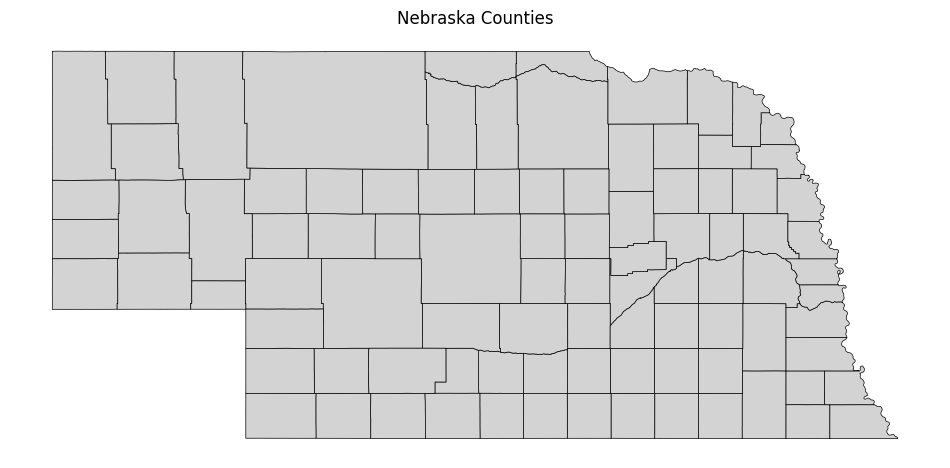

In [5]:
nebraska.plot(figsize=(12, 6), color='lightgrey', edgecolor='black', linewidth=0.5)
plt.title("Nebraska Counties")
plt.axis('off')
plt.show()

In [7]:
query = """SELECT l.areasymbol, l.areaname, mu.musym, mu.muname, 
           co.comppct_r, hz.ph1to1h2o_r
           FROM legend l
           JOIN mapunit mu ON mu.lkey = l.lkey
           JOIN component co ON co.mukey = mu.mukey
           JOIN chorizon hz ON hz.cokey = co.cokey
           WHERE l.areasymbol LIKE 'NE%'
           AND hz.ph1to1h2o_r IS NOT NULL"""

payload = {"query": query, "format": "json+columnname"}

response = requests.post(url, data=payload)
print(response.status_code)
print(response.text[:500])

200
{"Table":[["areasymbol","areaname","musym","muname","comppct_r","ph1to1h2o_r"],["NE123","Morrill County, Nebraska","5144","Busher-Tassel loamy very fine sands, 9 to 20 percent slopes","35","7.9"],["NE123","Morrill County, Nebraska","5144","Busher-Tassel loamy very fine sands, 9 to 20 percent slopes","35","7.9"],["NE111","Lincoln County, Nebraska","4122","Holdrege and Uly silt loams, 7 to 11 percent slopes","10","7.2"],["NE111","Lincoln County, Nebraska","4122","Holdrege and Uly silt loams, 7 to 


In [9]:
import json

data = response.json()
rows = data['Table']
headers = rows[0]
df = pd.DataFrame(rows[1:], columns=headers)

# Convert pH to numeric
df['ph1to1h2o_r'] = pd.to_numeric(df['ph1to1h2o_r'])

print(f"Loaded {len(df)} soil records")
df.head()

Loaded 77328 soil records


,areasymbol,areaname,musym,muname,comppct_r,ph1to1h2o_r
0,NE123,"Morrill County, Nebraska",5144,"Busher-Tassel loamy very fine sands, 9 to 20 p...",35,7.9
1,NE123,"Morrill County, Nebraska",5144,"Busher-Tassel loamy very fine sands, 9 to 20 p...",35,7.9
2,NE111,"Lincoln County, Nebraska",4122,"Holdrege and Uly silt loams, 7 to 11 percent s...",10,7.2
3,NE111,"Lincoln County, Nebraska",4122,"Holdrege and Uly silt loams, 7 to 11 percent s...",10,6.7
4,NE111,"Lincoln County, Nebraska",4122,"Holdrege and Uly silt loams, 7 to 11 percent s...",10,7.2


In [10]:
# Extract county name and calculate weighted average pH per county
df['comppct_r'] = pd.to_numeric(df['comppct_r'])

# Pull clean county name from areaname (remove ", Nebraska")
df['county'] = df['areaname'].str.replace(', Nebraska', '', regex=False).str.strip()

# Weighted average pH by county
county_ph = df.groupby('county').apply(
    lambda x: (x['ph1to1h2o_r'] * x['comppct_r']).sum() / x['comppct_r'].sum()
).reset_index()

county_ph.columns = ['county', 'avg_ph']
county_ph = county_ph.sort_values('avg_ph', ascending=False)

print(f"{len(county_ph)} counties with pH data")
county_ph.head(10)

93 counties with pH data


,county,avg_ph
28,Dundy County,7.794262
78,Scotts Bluff County,7.741405
43,Hitchcock County,7.737147
72,Red Willow County,7.629928
22,Dawes County,7.621980
82,Sioux County,7.607287
42,Hayes County,7.586606
3,Banner County,7.556212
32,Furnas County,7.541582
14,Chase County,7.533247


In [11]:
# Standardize county names for joining
nebraska['county'] = nebraska['NAME'] + ' County'

# Merge pH data onto county shapes
nebraska_ph = nebraska.merge(county_ph, on='county', how='left')

print(f"Counties with pH data: {nebraska_ph['avg_ph'].notna().sum()}")
print(f"Counties missing pH data: {nebraska_ph['avg_ph'].isna().sum()}")
nebraska_ph[['county', 'avg_ph']].head(10)

Counties with pH data: 92
Counties missing pH data: 1


,county,avg_ph
0,Cuming County,7.205059
1,Lancaster County,6.877413
2,Nuckolls County,7.117788
3,Keith County,7.458775
4,Phelps County,7.294694
5,Webster County,7.348759
6,Dakota County,7.470700
7,Boyd County,7.179913
8,Thomas County,6.730216
9,Holt County,6.855689


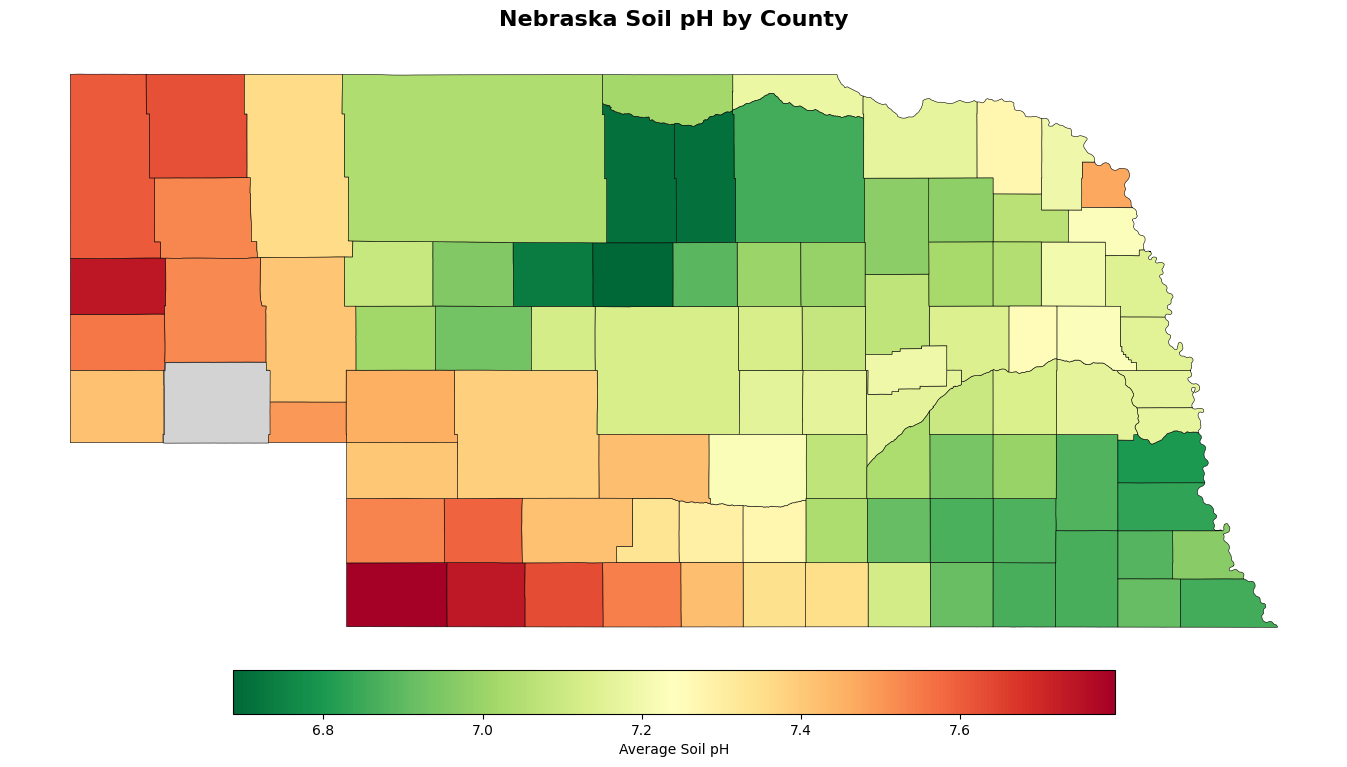

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

nebraska_ph.plot(
    column='avg_ph',
    ax=ax,
    cmap='RdYlGn_r',
    legend=True,
    legend_kwds={
        'label': 'Average Soil pH',
        'orientation': 'horizontal',
        'shrink': 0.6,
        'pad': 0.02
    },
    edgecolor='black',
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}
)

ax.set_title('Nebraska Soil pH by County', fontsize=16, fontweight='bold', pad=15)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('nebraska_soil_ph.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
query_p = """SELECT l.areasymbol, l.areaname, 
           co.comppct_r, hz.pbray1_r
           FROM legend l
           JOIN mapunit mu ON mu.lkey = l.lkey
           JOIN component co ON co.mukey = mu.mukey
           JOIN chorizon hz ON hz.cokey = co.cokey
           WHERE l.areasymbol LIKE 'NE%'
           AND hz.pbray1_r IS NOT NULL"""

payload_p = {"query": query_p, "format": "json+columnname"}

response_p = requests.post(url, data=payload_p)
print(response_p.status_code)
print(response_p.text[:500])

200
{}


In [15]:
query_p = """SELECT l.areasymbol, l.areaname, 
           co.comppct_r, hz.ph1to1h2o_r, hz.om_r
           FROM legend l
           JOIN mapunit mu ON mu.lkey = l.lkey
           JOIN component co ON co.mukey = mu.mukey
           JOIN chorizon hz ON hz.cokey = co.cokey
           WHERE l.areasymbol LIKE 'NE%'
           AND hz.om_r IS NOT NULL"""

payload_p = {"query": query_p, "format": "json+columnname"}

response_p = requests.post(url, data=payload_p)
print(response_p.status_code)
print(response_p.text[:500])

200
{"Table":[["areasymbol","areaname","comppct_r","ph1to1h2o_r","om_r"],["NE103","Keya Paha County, Nebraska","100","7","2"],["NE103","Keya Paha County, Nebraska","100","7.5","1"],["NE103","Keya Paha County, Nebraska","100",null,"0.25"],["NE107","Knox County, Nebraska","3","7.3","0.25"],["NE107","Knox County, Nebraska","3","7.9","0.5"],["NE107","Knox County, Nebraska","3","7.9","0.75"],["NE107","Knox County, Nebraska","3","7.5","3"],["NE107","Knox County, Nebraska","3","6.5","0.25"],["NE107","Knox 


In [16]:
data_p = response_p.json()
rows_p = data_p['Table']
headers_p = rows_p[0]
df_p = pd.DataFrame(rows_p[1:], columns=headers_p)

# Convert to numeric
df_p['comppct_r'] = pd.to_numeric(df_p['comppct_r'])
df_p['om_r'] = pd.to_numeric(df_p['om_r'])

# Clean county name
df_p['county'] = df_p['areaname'].str.replace(', Nebraska', '', regex=False).str.strip()

# Weighted average organic matter by county
county_om = df_p.groupby('county').apply(
    lambda x: (x['om_r'] * x['comppct_r']).sum() / x['comppct_r'].sum()
).reset_index()

county_om.columns = ['county', 'avg_om']

print(f"{len(county_om)} counties with organic matter data")
county_om.sort_values('avg_om', ascending=False).head(10)

93 counties with organic matter data


,county,avg_om
2,Arthur County,8.614317
45,Hooker County,6.549674
37,Grant County,6.232505
59,McPherson County,5.192270
15,Cherry County,4.001681
34,Garden County,2.365315
80,Sheridan County,2.279544
91,Wheeler County,2.132966
6,Box Butte County,2.030089
92,York County,2.024610


In [17]:
# Count records per county for pH dataset
ph_counts = df.groupby('county').size().reset_index(name='ph_count')

# Count records per county for organic matter dataset
om_counts = df_p.groupby('county').size().reset_index(name='om_count')

# Merge counts in
county_ph_full = county_ph.merge(ph_counts, on='county')
county_om_full = county_om.merge(om_counts, on='county')

# Look at organic matter counts sorted by avg value to check Arthur County
county_om_full.sort_values('avg_om', ascending=False).head(10)

,county,avg_om,om_count
2,Arthur County,8.614317,521
45,Hooker County,6.549674,564
37,Grant County,6.232505,611
59,McPherson County,5.192270,528
15,Cherry County,4.001681,1307
34,Garden County,2.365315,848
80,Sheridan County,2.279544,1399
91,Wheeler County,2.132966,653
6,Box Butte County,2.030089,1164
92,York County,2.024610,477


In [18]:
county_ph_full = county_ph.merge(ph_counts, on='county')
county_ph_full.sort_values('avg_ph', ascending=False).head(10)

,county,avg_ph,ph_count
0,Dundy County,7.794262,502
1,Scotts Bluff County,7.741405,838
2,Hitchcock County,7.737147,503
3,Red Willow County,7.629928,719
4,Dawes County,7.621980,1509
5,Sioux County,7.607287,1067
6,Hayes County,7.586606,288
7,Banner County,7.556212,655
8,Furnas County,7.541582,531
9,Chase County,7.533247,788


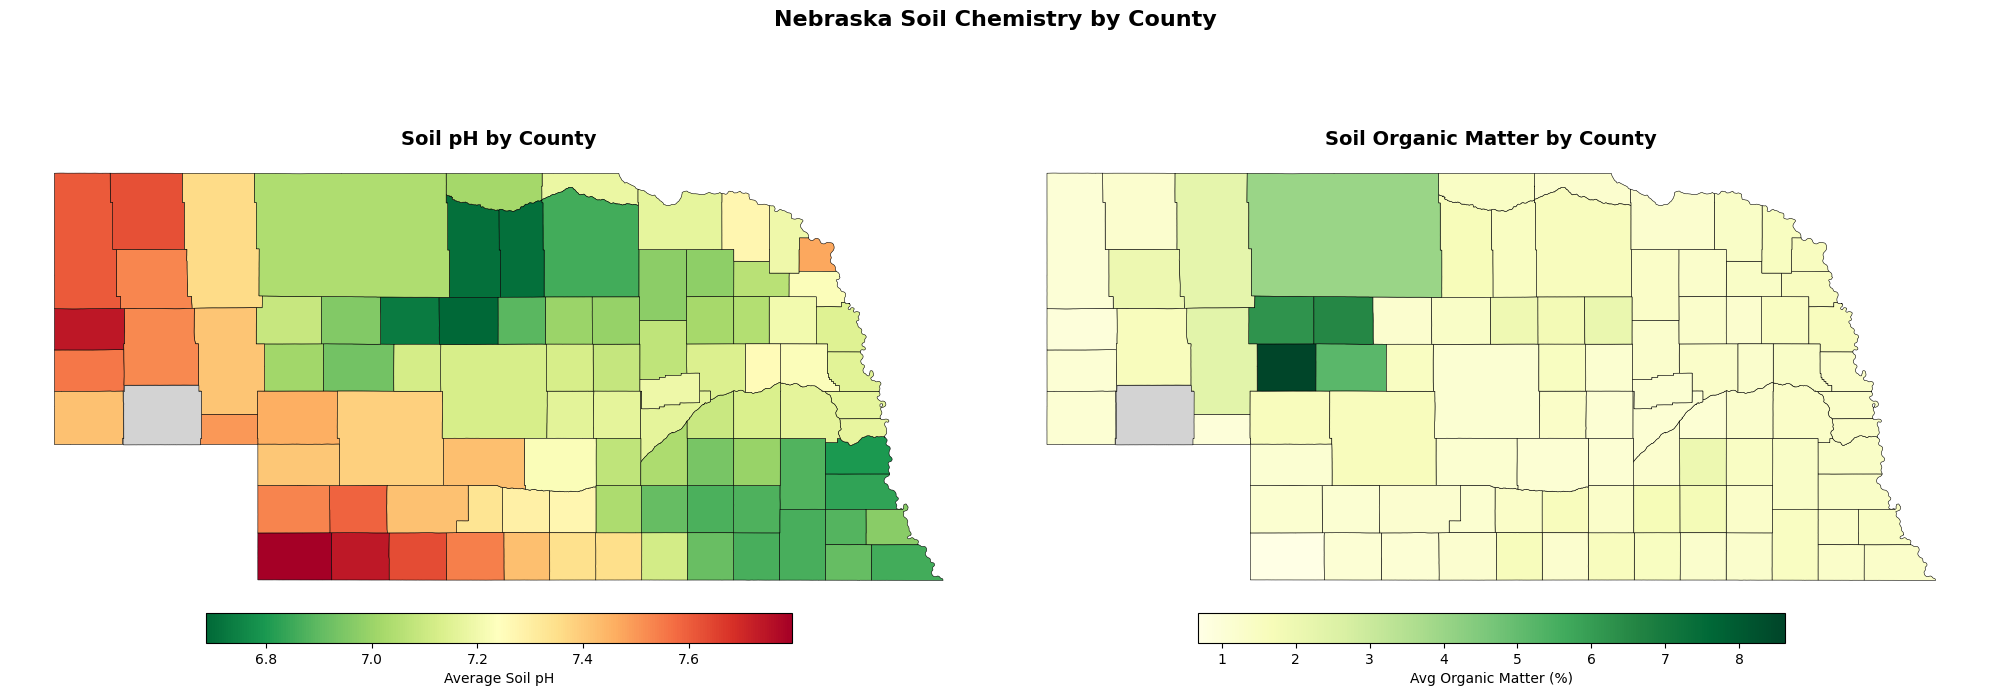

In [19]:
nebraska_ph = nebraska.merge(county_ph_full, on='county', how='left')
nebraska_om = nebraska.merge(county_om_full, on='county', how='left')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

nebraska_ph.plot(
    column='avg_ph',
    ax=ax1,
    cmap='RdYlGn_r',
    legend=True,
    legend_kwds={'label': 'Average Soil pH', 'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.02},
    edgecolor='black',
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey'}
)
ax1.set_title('Soil pH by County', fontsize=14, fontweight='bold')
ax1.set_axis_off()

nebraska_om.plot(
    column='avg_om',
    ax=ax2,
    cmap='YlGn',
    legend=True,
    legend_kwds={'label': 'Avg Organic Matter (%)', 'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.02},
    edgecolor='black',
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey'}
)
ax2.set_title('Soil Organic Matter by County', fontsize=14, fontweight='bold')
ax2.set_axis_off()

fig.suptitle('Nebraska Soil Chemistry by County', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nebraska_soil_ph_om.png', dpi=300, bbox_inches='tight')
plt.show()

ImportError: The 'mapclassify' package is required to use the 'scheme' keyword.

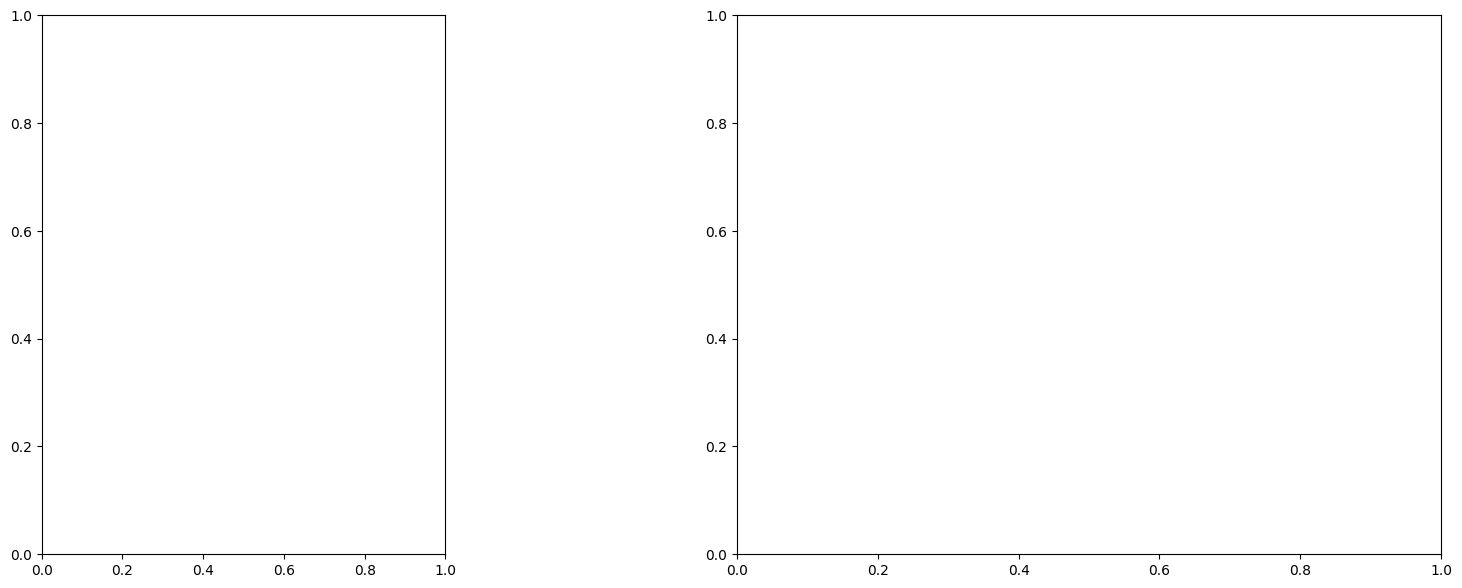

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

nebraska_ph.plot(
    column='avg_ph',
    ax=ax1,
    cmap='RdYlGn_r',
    scheme='quantiles',
    k=5,
    legend=True,
    legend_kwds={'title': 'Average Soil pH', 'loc': 'lower left', 'fontsize': 8},
    edgecolor='black',
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey'}
)
ax1.set_title('Soil pH by County', fontsize=14, fontweight='bold')
ax1.set_axis_off()

nebraska_om.plot(
    column='avg_om',
    ax=ax2,
    cmap='YlGn',
    scheme='quantiles',
    k=5,
    legend=True,
    legend_kwds={'title': 'Avg Organic Matter (%)', 'loc': 'lower left', 'fontsize': 8},
    edgecolor='black',
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey'}
)
ax2.set_title('Soil Organic Matter by County', fontsize=14, fontweight='bold')
ax2.set_axis_off()

fig.suptitle('Nebraska Soil Chemistry by County', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nebraska_soil_ph_om.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
!pip install mapclassify

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 882.2/882.2 kB 15.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 22.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 25.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 18.2 MB/s eta 0:00:0000:0100:01


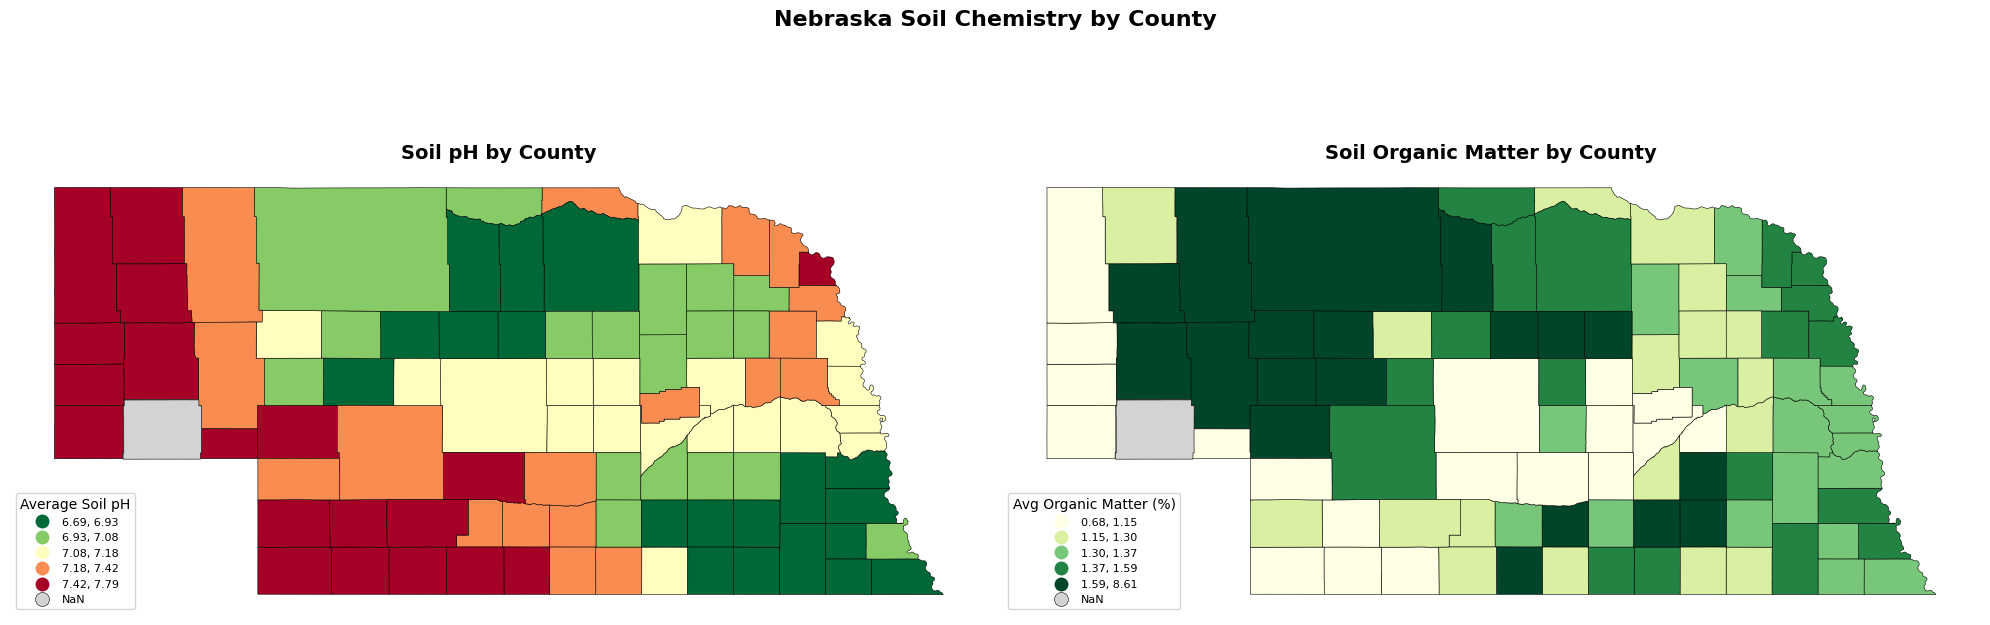

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

nebraska_ph.plot(
    column='avg_ph',
    ax=ax1,
    cmap='RdYlGn_r',
    scheme='quantiles',
    k=5,
    legend=True,
    legend_kwds={'title': 'Average Soil pH', 'loc': 'lower left', 'fontsize': 8},
    edgecolor='black',
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey'}
)
ax1.set_title('Soil pH by County', fontsize=14, fontweight='bold')
ax1.set_axis_off()

nebraska_om.plot(
    column='avg_om',
    ax=ax2,
    cmap='YlGn',
    scheme='quantiles',
    k=5,
    legend=True,
    legend_kwds={'title': 'Avg Organic Matter (%)', 'loc': 'lower left', 'fontsize': 8},
    edgecolor='black',
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey'}
)
ax2.set_title('Soil Organic Matter by County', fontsize=14, fontweight='bold')
ax2.set_axis_off()

fig.suptitle('Nebraska Soil Chemistry by County', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nebraska_soil_ph_om.png', dpi=300, bbox_inches='tight')
plt.show()

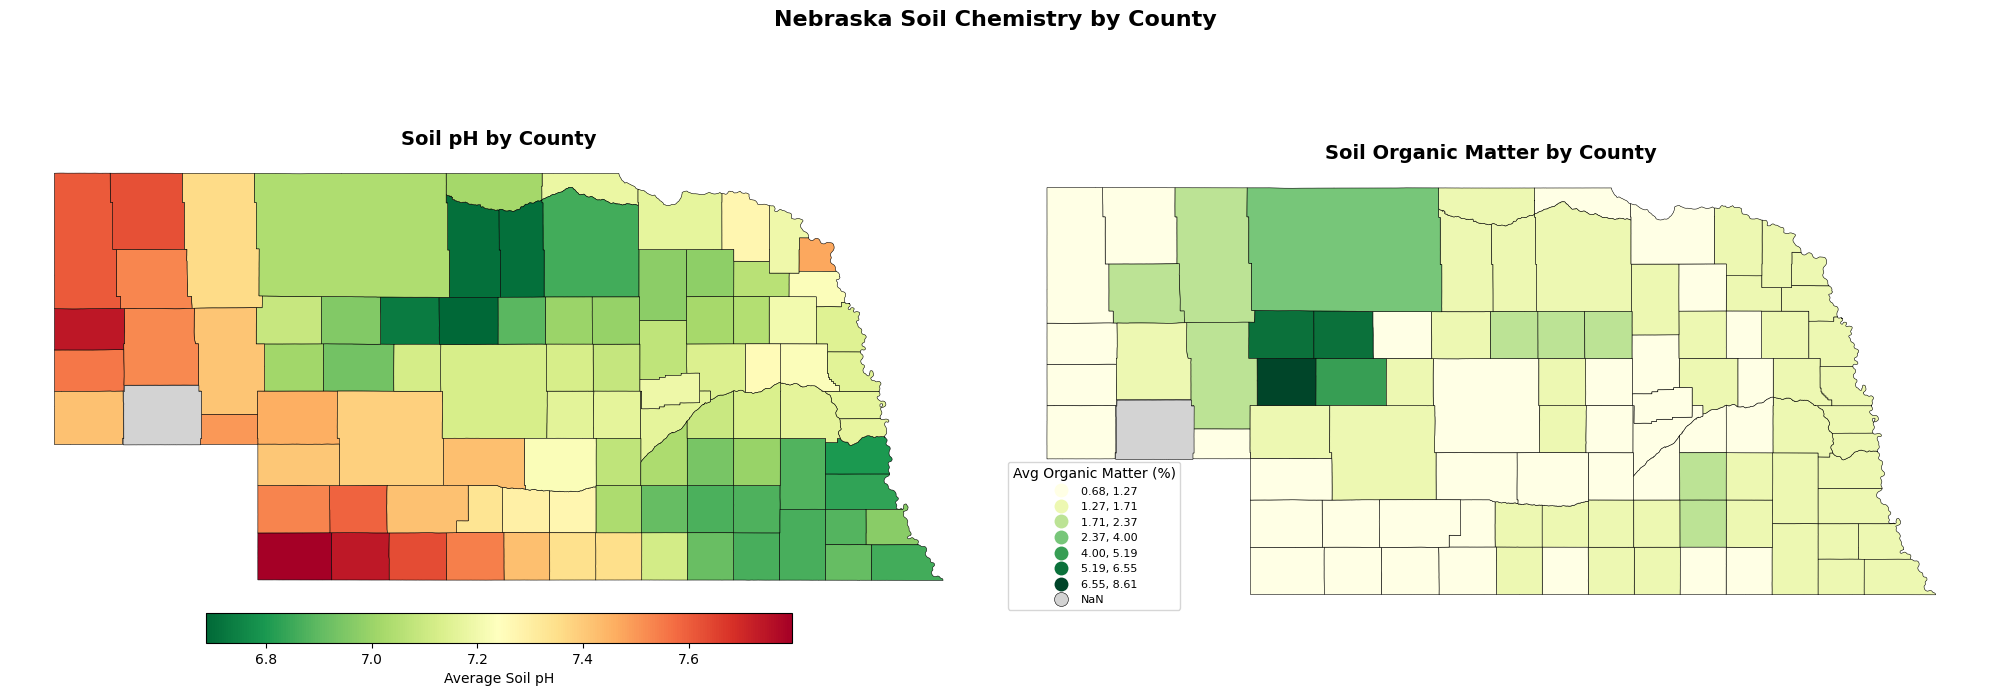

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# pH - continuous
nebraska_ph.plot(
    column='avg_ph',
    ax=ax1,
    cmap='RdYlGn_r',
    legend=True,
    legend_kwds={'label': 'Average Soil pH', 'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.02},
    edgecolor='black',
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey'}
)
ax1.set_title('Soil pH by County', fontsize=14, fontweight='bold')
ax1.set_axis_off()

# Organic matter - natural breaks with 7 categories
nebraska_om.plot(
    column='avg_om',
    ax=ax2,
    cmap='YlGn',
    scheme='natural_breaks',
    k=7,
    legend=True,
    legend_kwds={'title': 'Avg Organic Matter (%)', 'loc': 'lower left', 'fontsize': 8},
    edgecolor='black',
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey'}
)
ax2.set_title('Soil Organic Matter by County', fontsize=14, fontweight='bold')
ax2.set_axis_off()

fig.suptitle('Nebraska Soil Chemistry by County', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nebraska_soil_ph_om.png', dpi=300, bbox_inches='tight')
plt.show()

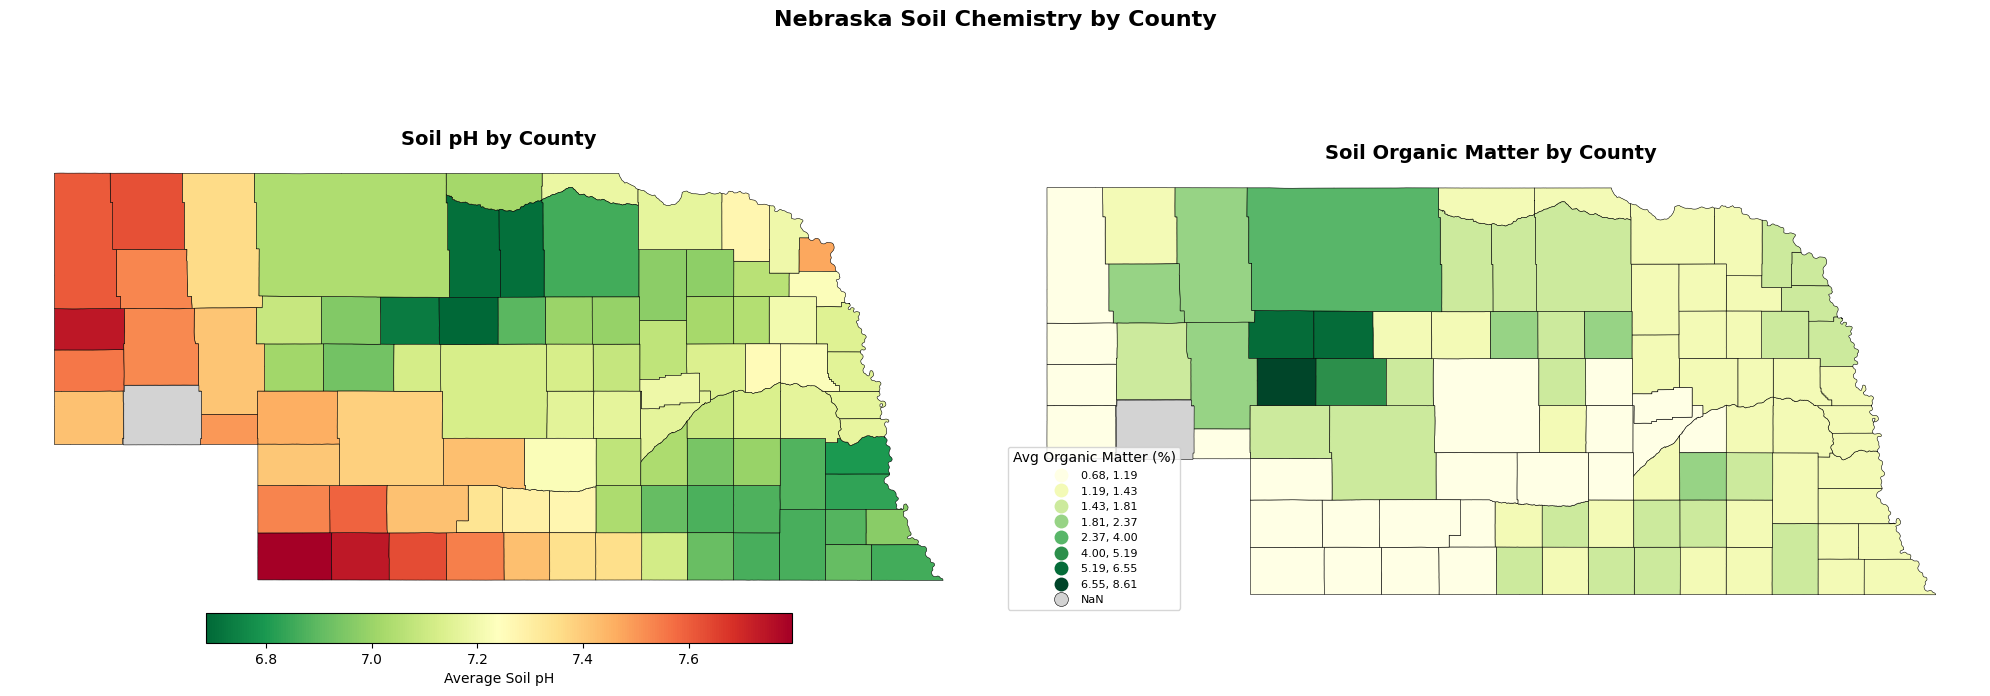

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

nebraska_ph.plot(
    column='avg_ph',
    ax=ax1,
    cmap='RdYlGn_r',
    legend=True,
    legend_kwds={'label': 'Average Soil pH', 'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.02},
    edgecolor='black',
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey'}
)
ax1.set_title('Soil pH by County', fontsize=14, fontweight='bold')
ax1.set_axis_off()

nebraska_om.plot(
    column='avg_om',
    ax=ax2,
    cmap='YlGn',
    scheme='natural_breaks',
    k=8,
    legend=True,
    legend_kwds={'title': 'Avg Organic Matter (%)', 'loc': 'lower left', 'fontsize': 8},
    edgecolor='black',
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey'}
)
ax2.set_title('Soil Organic Matter by County', fontsize=14, fontweight='bold')
ax2.set_axis_off()

fig.suptitle('Nebraska Soil Chemistry by County', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nebraska_soil_ph_om.png', dpi=300, bbox_inches='tight')
plt.show()

TypeError: Legend.__init__() got an unexpected keyword argument 'orientation'

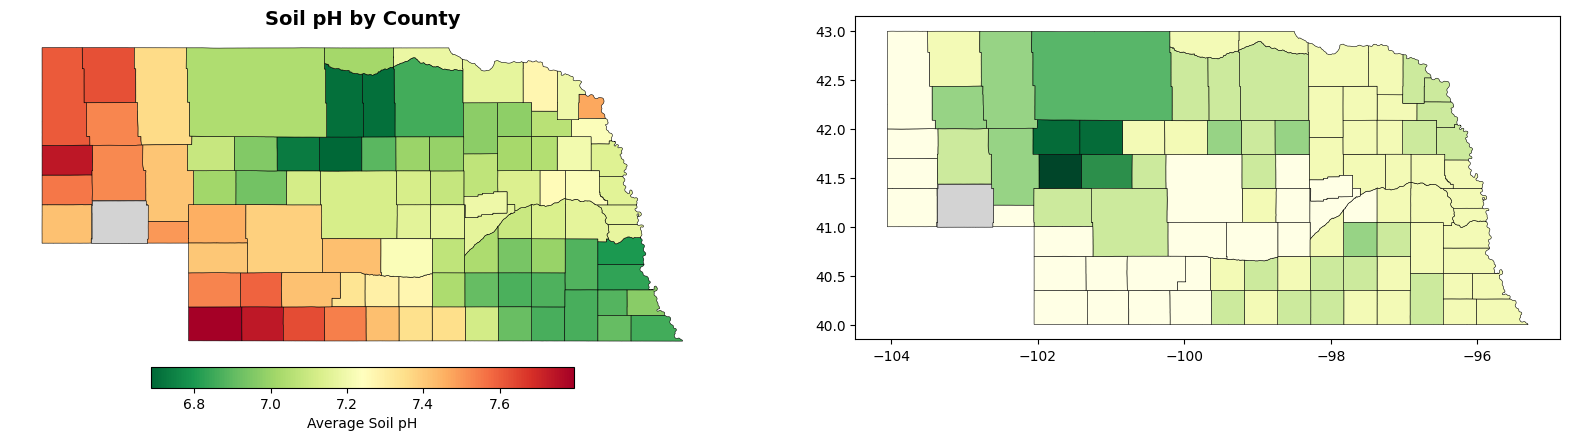

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

nebraska_ph.plot(
    column='avg_ph',
    ax=ax1,
    cmap='RdYlGn_r',
    legend=True,
    legend_kwds={'label': 'Average Soil pH', 'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.02},
    edgecolor='black',
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey'}
)
ax1.set_title('Soil pH by County', fontsize=14, fontweight='bold')
ax1.set_axis_off()

nebraska_om.plot(
    column='avg_om',
    ax=ax2,
    cmap='YlGn',
    scheme='natural_breaks',
    k=8,
    legend=True,
    legend_kwds={
        'title': 'Avg Organic Matter (%)',
        'orientation': 'horizontal',
        'bbox_to_anchor': (0.5, -0.05),
        'loc': 'upper center',
        'fontsize': 8,
        'title_fontsize': 9,
        'ncol': 4
    },
    edgecolor='black',
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey'}
)
ax2.set_title('Soil Organic Matter by County', fontsize=14, fontweight='bold')
ax2.set_axis_off()

fig.suptitle('Nebraska Soil Chemistry by County', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nebraska_soil_ph_om.png', dpi=300, bbox_inches='tight')
plt.show()

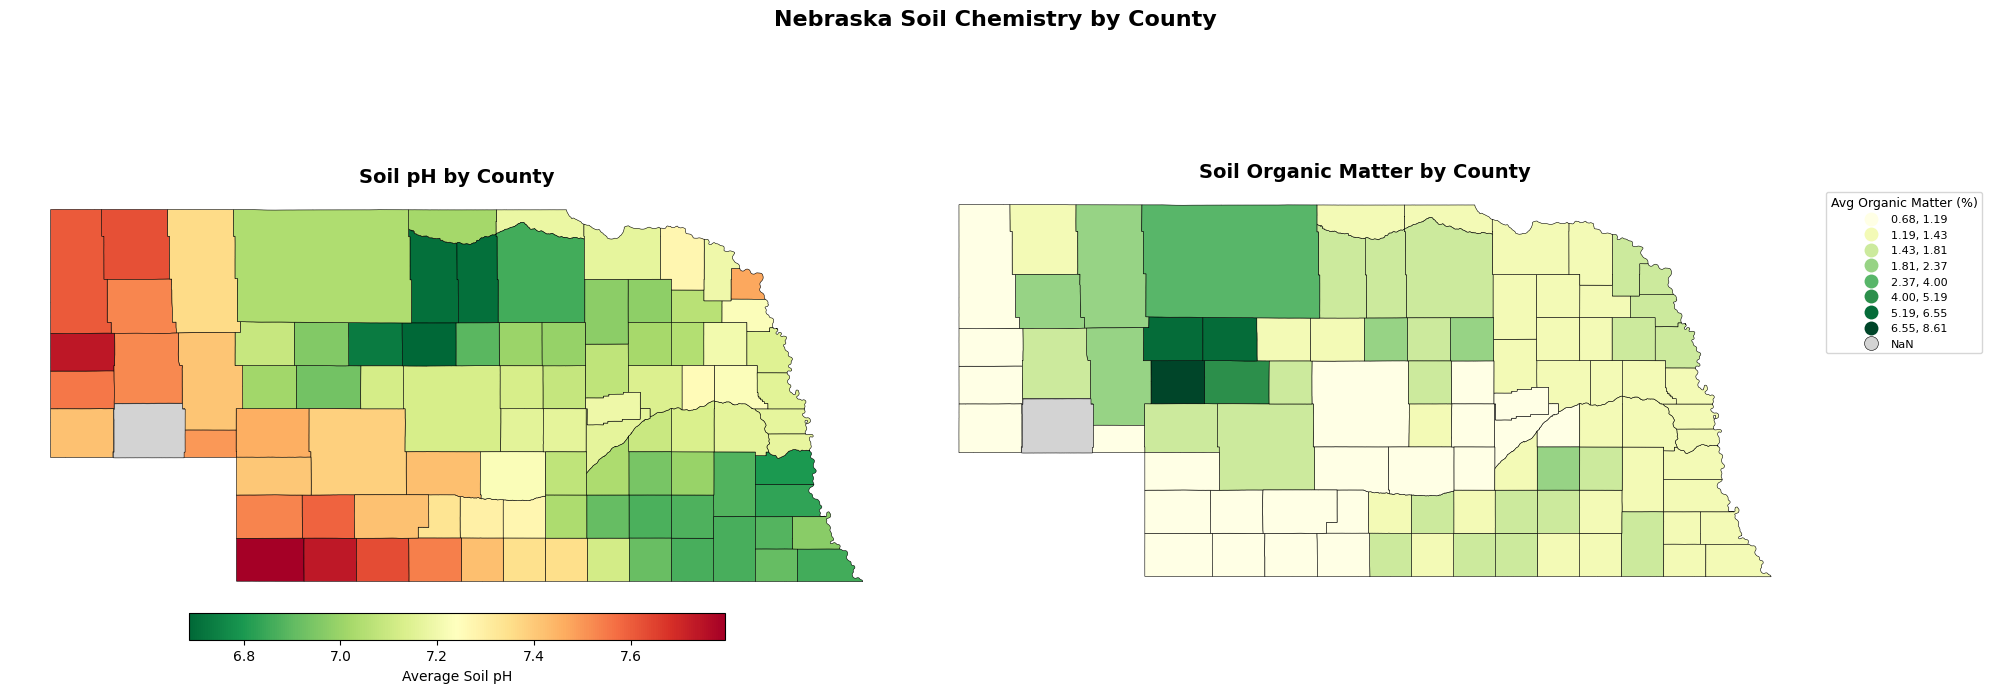

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

nebraska_ph.plot(
    column='avg_ph',
    ax=ax1,
    cmap='RdYlGn_r',
    legend=True,
    legend_kwds={'label': 'Average Soil pH', 'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.02},
    edgecolor='black',
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey'}
)
ax1.set_title('Soil pH by County', fontsize=14, fontweight='bold')
ax1.set_axis_off()

nebraska_om.plot(
    column='avg_om',
    ax=ax2,
    cmap='YlGn',
    scheme='natural_breaks',
    k=8,
    legend=True,
    legend_kwds={
        'title': 'Avg Organic Matter (%)',
        'loc': 'upper left',
        'bbox_to_anchor': (1.01, 1),
        'fontsize': 8,
        'title_fontsize': 9,
        'frameon': True
    },
    edgecolor='black',
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey'}
)
ax2.set_title('Soil Organic Matter by County', fontsize=14, fontweight='bold')
ax2.set_axis_off()

fig.suptitle('Nebraska Soil Chemistry by County', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nebraska_soil_ph_om.png', dpi=300, bbox_inches='tight')
plt.show()

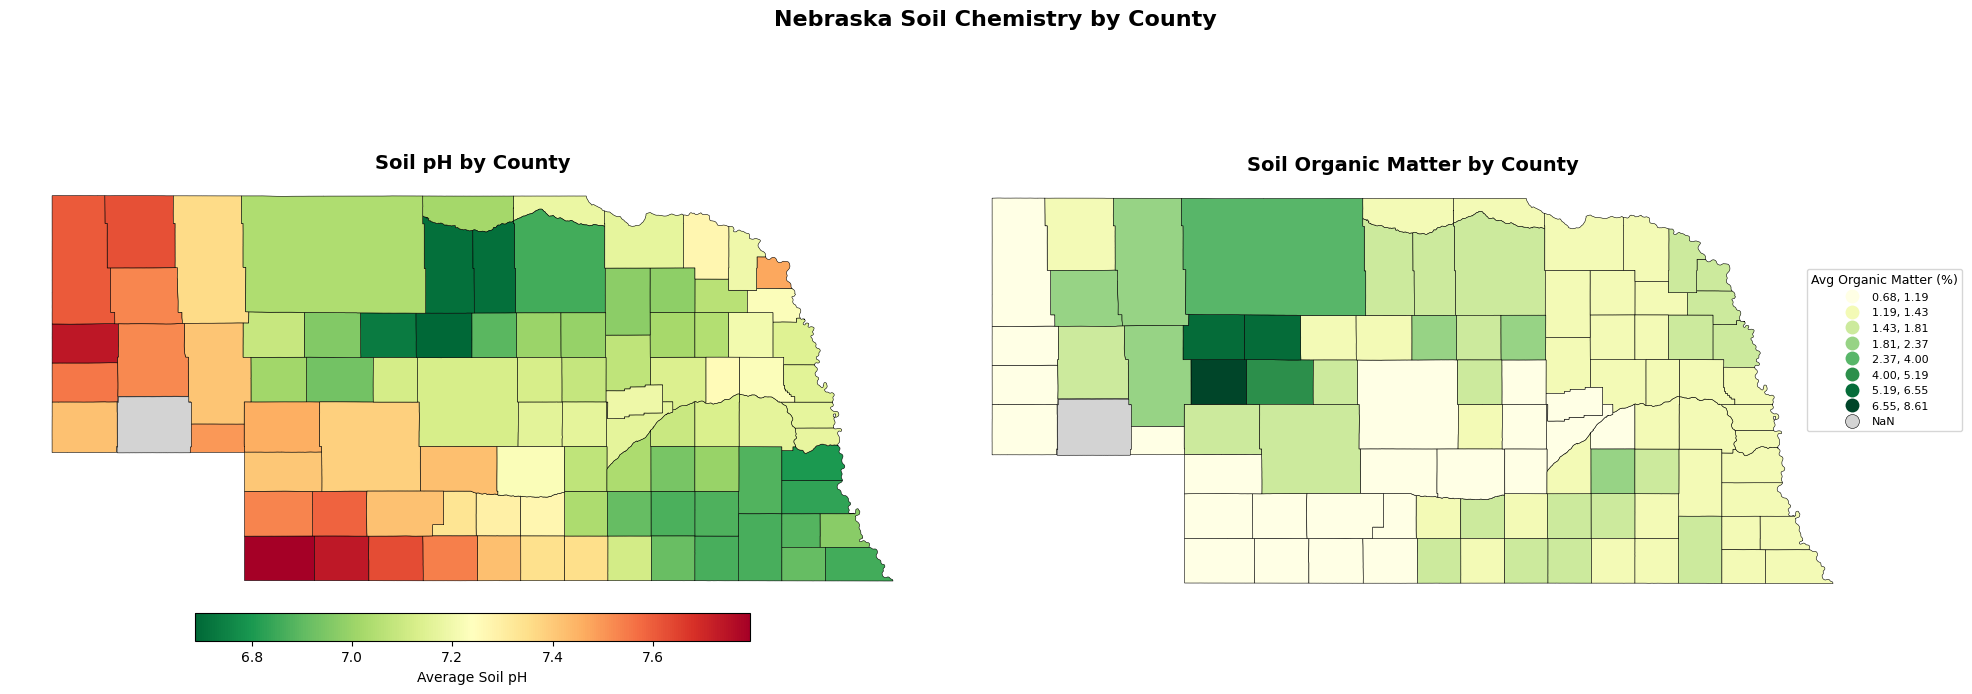

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

nebraska_ph.plot(
    column='avg_ph',
    ax=ax1,
    cmap='RdYlGn_r',
    legend=True,
    legend_kwds={'label': 'Average Soil pH', 'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.02},
    edgecolor='black',
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey'}
)
ax1.set_title('Soil pH by County', fontsize=14, fontweight='bold')
ax1.set_axis_off()

nebraska_om.plot(
    column='avg_om',
    ax=ax2,
    cmap='YlGn',
    scheme='natural_breaks',
    k=8,
    legend=True,
    legend_kwds={
        'title': 'Avg Organic Matter (%)',
        'loc': 'upper left',
        'bbox_to_anchor': (0.92, 0.8),
        'fontsize': 8,
        'title_fontsize': 9,
        'frameon': True
    },
    edgecolor='black',
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey'}
)
ax2.set_title('Soil Organic Matter by County', fontsize=14, fontweight='bold')
ax2.set_axis_off()

fig.suptitle('Nebraska Soil Chemistry by County', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nebraska_soil_ph_om.png', dpi=300, bbox_inches='tight')
plt.show()